## 环境配置 + 数据加载

In [17]:
# ===================== 模块1：导入所需工具库 =====================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置中文显示，避免画图乱码
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

# ===================== 模块2：加载原始数据集 =====================
df = pd.read_csv("../data/raw/cs-training.csv", index_col=0)
# df = pd.read_csv("../data/processed/train_set_processed.csv", index_col=0)
# 注意：fold_1_train_oversampled.csv 在生成时保存为 index=False，这里不能用 index_col=0
# df = pd.read_csv("../data/processed/five_folds_oversampled/fold_1_train_oversampled.csv")

# 输出加载成功基础信息
print("="*60)
print("✅ 数据集加载成功！")
print(f"数据集总行数（用户样本量）：{df.shape[0]} 条")
print(f"数据集总列数（输入特征数+目标标签列）：{df.shape[1]} 列")
print("字段名：", df.columns.tolist())
print("="*60)

✅ 数据集加载成功！
数据集总行数（用户样本量）：150000 条
数据集总列数（输入特征数+目标标签列）：11 列
字段名： ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


## 数据基础信息 + 全自动缺失值检测

In [18]:
# ===================== 模块4：数据基本信息探查 + 缺失值全列检测 =====================
print("\n📊 数据类型与非空值统计：")
df.info()
print("="*60)

print("\n📈 数值特征全局统计分布：")
print(df.describe().round(2))
print("="*60)

# ===================== 【优化】全自动缺失值排查：遍历所有列，自动识别有缺失的列 =====================
print("\n⚠️  【全自动排查】所有列缺失值统计（仅展示存在缺失的列）：")
missing_stats = pd.DataFrame({
    "缺失值数量": df.isnull().sum(),
    "缺失比例(%)": (df.isnull().sum() / df.shape[0] * 100).round(2)
})
# 自动过滤：只显示有缺失值的列，无需手动指定列名
missing_result = missing_stats[missing_stats["缺失值数量"] > 0].sort_values("缺失比例(%)", ascending=False)

if missing_result.empty:
    print("✅ 数据集无任何缺失值！")
else:
    print(missing_result)
print("="*60)


📊 数据类型与非空值统计：
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
d

## 全自动异常值检测（IQR 法，全列扫描

In [19]:
# ===================== 【新增核心】全自动异常值排查（全列检测，无硬编码） =====================
# 异常值检测方法：IQR四分位法（通用标准EDA方法）
print("\n🚨 【全自动排查】所有数值列异常值统计（仅展示存在异常的列）：")
print("检测方法：IQR四分位法 (Q1-1.5*IQR  ~  Q3+1.5*IQR)")
print("-"*60)

outlier_result = []
# 自动遍历所有数值型列，检测异常值
for col in df.select_dtypes(include=[np.number]).columns:
    # 过滤目标标签列（SeriousDlqin2yrs是分类标签，不检测异常）
    if col == "SeriousDlqin2yrs":
        continue

    series = df[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # 统计异常值数量
    outlier_num = ((series < lower) | (series > upper)).sum()
    outlier_rate = round(outlier_num / len(series) * 100, 2) if len(series) > 0 else 0

    if outlier_num > 0:
        outlier_result.append({
            "特征列名": col,
            "异常值数量": outlier_num,
            "异常比例(%)": outlier_rate,
            "正常范围": f"[{lower:.2f}, {upper:.2f}]",
            "最小值": series.min(),
            "最大值": series.max()
        })

# 输出异常值结果
if outlier_result:
    outlier_df = pd.DataFrame(outlier_result).sort_values("异常值数量", ascending=False)
    print(outlier_df.to_string(index=False))
else:
    print("✅ 数据集无任何异常值！")
print("="*70)


🚨 【全自动排查】所有数值列异常值统计（仅展示存在异常的列）：
检测方法：IQR四分位法 (Q1-1.5*IQR  ~  Q3+1.5*IQR)
------------------------------------------------------------
                                特征列名  异常值数量  异常比例(%)                 正常范围  最小值       最大值
                           DebtRatio  31311    20.87        [-0.86, 1.91]  0.0  329664.0
NumberOfTime30-59DaysPastDueNotWorse  23982    15.99         [0.00, 0.00]  0.0      98.0
                  NumberOfDependents  13336     9.13        [-1.50, 2.50]  0.0      20.0
             NumberOfTimes90DaysLate   8338     5.56         [0.00, 0.00]  0.0      98.0
NumberOfTime60-89DaysPastDueNotWorse   7604     5.07         [0.00, 0.00]  0.0      98.0
                       MonthlyIncome   4879     4.06 [-3873.50, 15522.50]  0.0 3008750.0
     NumberOfOpenCreditLinesAndLoans   3980     2.65       [-4.00, 20.00]  0.0      58.0
        NumberRealEstateLoansOrLines    793     0.53        [-3.00, 5.00]  0.0      54.0
RevolvingUtilizationOfUnsecuredLines    763     0.51        [-0.

## 【新增 Cell】进一步数据分析（DebtRatio / 循环额度 / 逾期异常值统计）


🔍 【进一步数据分析】异常值专项统计

📌 1. 三类逾期次数字段 96/98 异常值统计：
- NumberOfTime30-59DaysPastDueNotWorse：值=96 共 5 个 | 值=98 共 264 个
- NumberOfTime60-89DaysPastDueNotWorse：值=96 共 5 个 | 值=98 共 264 个
- NumberOfTimes90DaysLate：值=96 共 5 个 | 值=98 共 264 个

📊 2. DebtRatio（债务率）分组分布统计：
DebtRatio_Group
0~10       121006
10~100       4592
100~200      1301
200~300       833
300~400       834
400~500       820
500~600       876
600~700       721
700~800       709
>800        18308
Name: count, dtype: int64


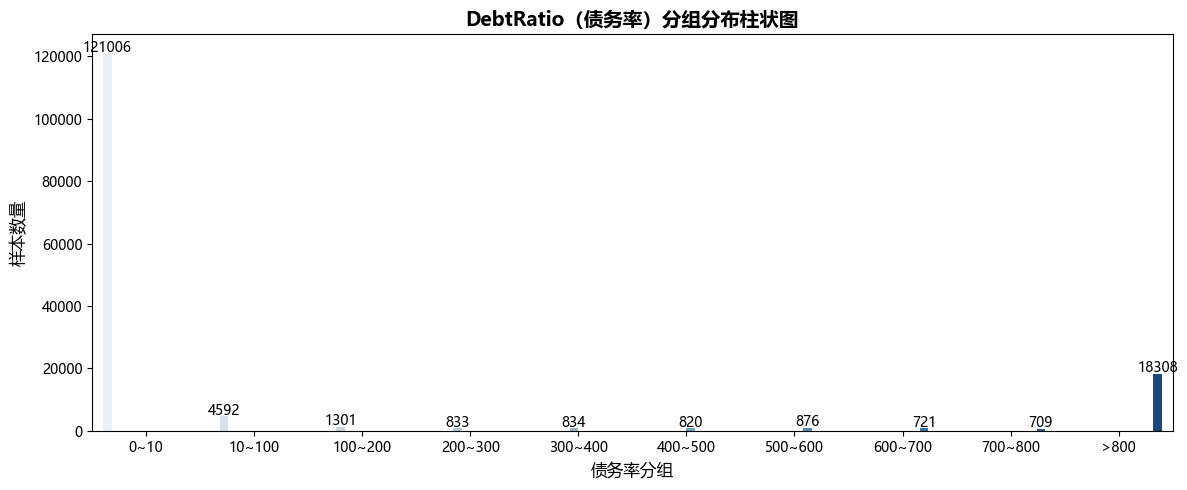


📊 3. 循环额度使用率分组分布统计：
RevolvingUtil_Group
0~1        146662
1~50         3106
50~75           5
75~100          4
100~125         2
125~150         2
150~175         0
175~200         0
>200          219
Name: count, dtype: int64


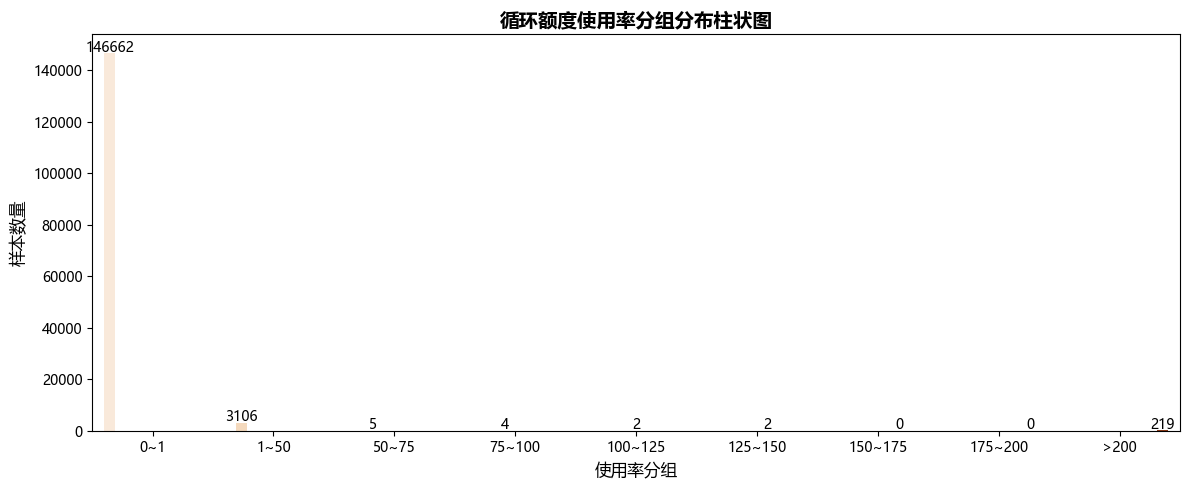


📈 4. 间隔5000 数据量变化趋势折线图（带数值标注）


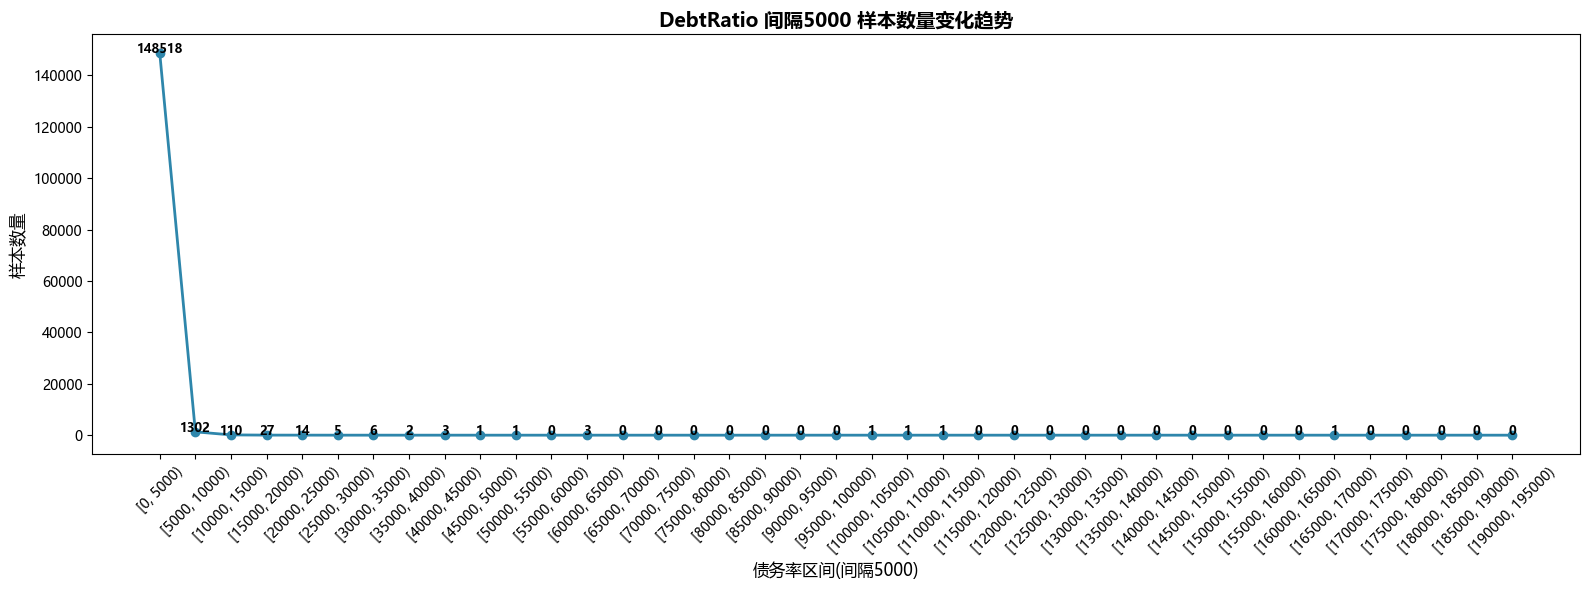

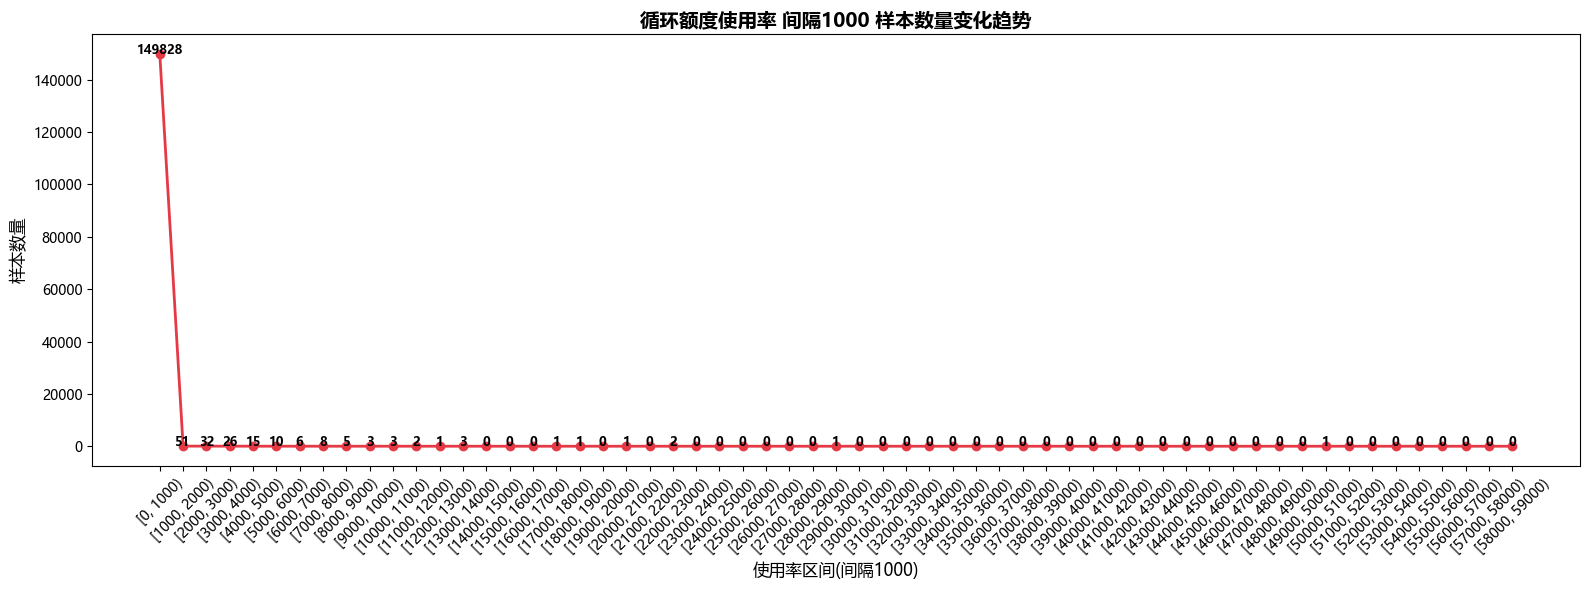


✅ 进一步数据分析完成！


In [20]:
# ===================== 【新增模块】进一步数据分析：异常值深度探查 =====================
# 功能1：统计3类逾期字段中 96、98 异常值的数量
# 功能2：DebtRatio 固定间隔分组可视化
# 功能3：循环额度使用率 固定间隔分组可视化
# 功能4：新增！间隔10折线图展示数据量变化趋势

print("\n🔍 【进一步数据分析】异常值专项统计")
print("="*70)

# ---------------------- 1. 三类逾期字段：统计96、98异常值数量 ----------------------
print("\n📌 1. 三类逾期次数字段 96/98 异常值统计：")
due_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]
for col in due_columns:
    count_96 = (df[col] == 96).sum()
    count_98 = (df[col] == 98).sum()
    print(f"- {col}：值=96 共 {count_96} 个 | 值=98 共 {count_98} 个")

# ---------------------- 2. DebtRatio 固定间隔分组 + 柱状图 ----------------------
print("\n📊 2. DebtRatio（债务率）分组分布统计：")
# 固定分组区间（业务合理划分）
debt_bins = [0, 10,100, 200, 300, 400, 500, 600, 700, 800, float('inf')]
debt_labels = ["0~10", "10~100", "100~200", "200~300", "300~400", "400~500", "500~600", "600~700", "700~800", ">800"]
df['DebtRatio_Group'] = pd.cut(df['DebtRatio'], bins=debt_bins, labels=debt_labels, right=False)
debt_group_count = df['DebtRatio_Group'].value_counts().sort_index()
print(debt_group_count)

# 绘制柱状图 + 图表大小控制：figsize=(宽, 高) 单位英寸
plt.figure(figsize=(12, 5))
ax1 = sns.barplot(
    x=debt_group_count.index,
    y=debt_group_count.values,
    hue=debt_group_count.index,
    palette="Blues",
    legend=False
)
plt.title("DebtRatio（债务率）分组分布柱状图", fontsize=14, fontweight="bold")
plt.xlabel("债务率分组", fontsize=12)
plt.ylabel("样本数量", fontsize=12)
for p in ax1.patches:
    ax1.text(p.get_x() + p.get_width() / 2., p.get_height() + 500, f'{int(p.get_height())}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("../data/output-img/DebtRatio分组分布柱状图.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------- 3. 循环额度使用率 固定间隔分组 + 柱状图 ----------------------
print("\n📊 3. 循环额度使用率分组分布统计：")
util_bins = [0, 1, 50, 75, 100, 125, 150, 175, 200, float('inf')]
util_labels = ["0~1", "1~50", "50~75", "75~100", "100~125", "125~150", "150~175", "175~200", ">200"]
# 这里应按使用率列分组，不能按 index 分组
df['RevolvingUtil_Group'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], bins=util_bins, labels=util_labels, right=False)
util_group_count = df['RevolvingUtil_Group'].value_counts().sort_index()
print(util_group_count)

plt.figure(figsize=(12, 5))
ax2 = sns.barplot(
    x=util_group_count.index,
    y=util_group_count.values,
    hue=util_group_count.index,
    palette="Oranges",
    legend=False
)
plt.title("循环额度使用率分组分布柱状图", fontsize=14, fontweight="bold")
plt.xlabel("使用率分组", fontsize=12)
plt.ylabel("样本数量", fontsize=12)
for p in ax2.patches:
    ax2.text(p.get_x() + p.get_width() / 2., p.get_height() + 500, f'{int(p.get_height())}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("../data/output-img/循环额度使用率分组分布柱状图.png", dpi=300, bbox_inches="tight")
plt.show()

# ===================== ✨【带数值标注】间隔5000 折线图：1秒出图 =====================
print("\n📈 4. 间隔5000 数据量变化趋势折线图（带数值标注）")
# ---------------------- 4.1 DebtRatio 间隔5000折线图（带数值标签） ----------------------
dr_bins = list(range(0, 200000, 5000))
df['DR_10Group'] = pd.cut(df['DebtRatio'], bins=dr_bins, right=False)
dr_count = df['DR_10Group'].value_counts().sort_index()

plt.figure(figsize=(16, 6))
plt.plot(dr_count.index.astype(str), dr_count.values, marker='o', color='#2E86AB', linewidth=2, markersize=6)
for i, value in enumerate(dr_count.values):
    plt.text(i, value + 100, str(value), ha='center', fontsize=9, fontweight='bold')

plt.title('DebtRatio 间隔5000 样本数量变化趋势', fontsize=14, fontweight='bold')
plt.xlabel('债务率区间(间隔5000)', fontsize=12)
plt.ylabel('样本数量', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/output-img/DebtRatio_间隔5000折线图.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------- 4.2 循环额度使用率 间隔1000折线图（带数值标签） ----------------------
ru_bins = list(range(0, 60000, 1000))
df['RU_10Group'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], bins=ru_bins, right=False)
ru_count = df['RU_10Group'].value_counts().sort_index()

plt.figure(figsize=(16, 6))
plt.plot(ru_count.index.astype(str), ru_count.values, marker='o', color='#E63946', linewidth=2, markersize=6)
for i, value in enumerate(ru_count.values):
    plt.text(i, value + 20, str(value), ha='center', fontsize=9, fontweight='bold')

plt.title('循环额度使用率 间隔1000 样本数量变化趋势', fontsize=14, fontweight='bold')
plt.xlabel('使用率区间(间隔1000)', fontsize=12)
plt.ylabel('样本数量', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/output-img/循环额度使用率_间隔1000折线图.png", dpi=300, bbox_inches="tight")
plt.show()

# 删除临时分组列，不影响原数据
df.drop(['DebtRatio_Group', 'RevolvingUtil_Group', 'DR_10Group', 'RU_10Group'], axis=1, inplace=True)
print("\n✅ 进一步数据分析完成！")
print("="*70)

## 计算最大 1% 分界值（99 分位数）

In [21]:
# ===================== 【核心】计算最大1%数据分界值（99分位数） =====================
print("\n🎯 关键指标：最大1%数据分界值（异常值截断依据）")
print("="*70)

# 1. 计算 DebtRatio 99.5分位数（最大0.5%起始值）
dr_99 = df["DebtRatio"].quantile(0.80)
dr_total = len(df["DebtRatio"].dropna())
dr_top1_count = int(dr_total * 0.2)
print(f"📊 DebtRatio（债务率）")
print(f"总有效样本数：{dr_total}")
print(f"前1%最大数据量：{dr_top1_count} 条")
print(f"✅ 最大1%数据【起始分界值】：{dr_99:.2f}")
print(f"👉 处理建议：大于 {dr_99:.2f} 的值为极端异常值，建议截断")

print("-"*50)

# 2. 计算 循环额度使用率 99分位数（最大1%起始值）
ru_99 = df["RevolvingUtilizationOfUnsecuredLines"].quantile(0.995)
ru_total = len(df["RevolvingUtilizationOfUnsecuredLines"].dropna())
ru_top1_count = int(ru_total * 0.005)
print(f"📊 循环额度使用率")
print(f"总有效样本数：{ru_total}")
print(f"前1%最大数据量：{ru_top1_count} 条")
print(f"✅ 最大0.5%数据【起始分界值】：{ru_99:.2f}")
print(f"👉 处理建议：大于 {ru_99:.2f} 的值为极端异常值，建议截断")

print("="*70)


🎯 关键指标：最大1%数据分界值（异常值截断依据）
📊 DebtRatio（债务率）
总有效样本数：150000
前1%最大数据量：30000 条
✅ 最大1%数据【起始分界值】：4.00
👉 处理建议：大于 4.00 的值为极端异常值，建议截断
--------------------------------------------------
📊 循环额度使用率
总有效样本数：150000
前1%最大数据量：750 条
✅ 最大0.5%数据【起始分界值】：1.37
👉 处理建议：大于 1.37 的值为极端异常值，建议截断


## 目标标签分布统计

In [22]:
# ===================== 模块5：标签分布统计（核心：确认数据不平衡程度） =====================
print("\n🎯 目标标签（逾期/正常用户）分布统计：")
target_col = "SeriousDlqin2yrs"
label_count = df[target_col].value_counts()
label_ratio = df[target_col].value_counts(normalize=True) * 100

label_result = pd.DataFrame({
    "样本数量": label_count,
    "占总样本比例(%)": label_ratio.round(2)
})
label_result.index = ["正常用户(0)", "逾期用户(1)"]
print(label_result)
print("="*60)

imbalance_rate = label_count[0] / label_count[1]
print(f"⚖️  数据不平衡比例（正常样本:逾期样本）：{imbalance_rate:.2f} : 1")
print(f"结论：逾期样本仅占总样本的{label_ratio[1]:.2f}%，属于典型的不平衡二分类数据集")
print("="*60)


🎯 目标标签（逾期/正常用户）分布统计：
           样本数量  占总样本比例(%)
正常用户(0)  139974      93.32
逾期用户(1)   10026       6.68
⚖️  数据不平衡比例（正常样本:逾期样本）：13.96 : 1
结论：逾期样本仅占总样本的6.68%，属于典型的不平衡二分类数据集


## 标签分布可视化

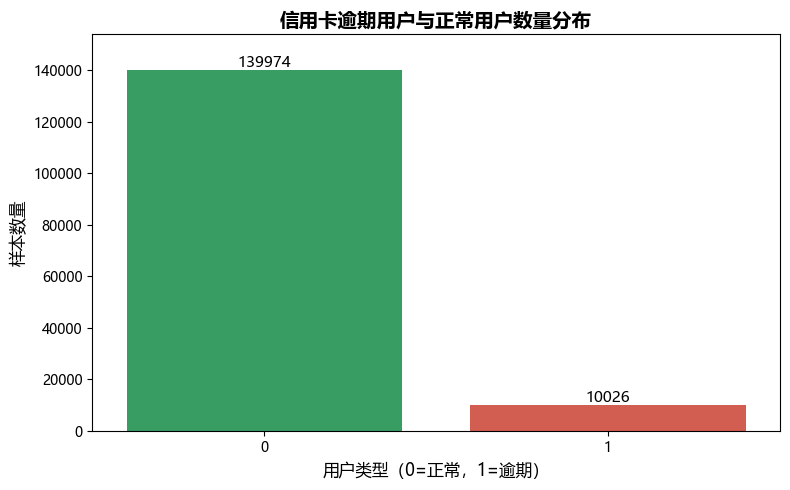

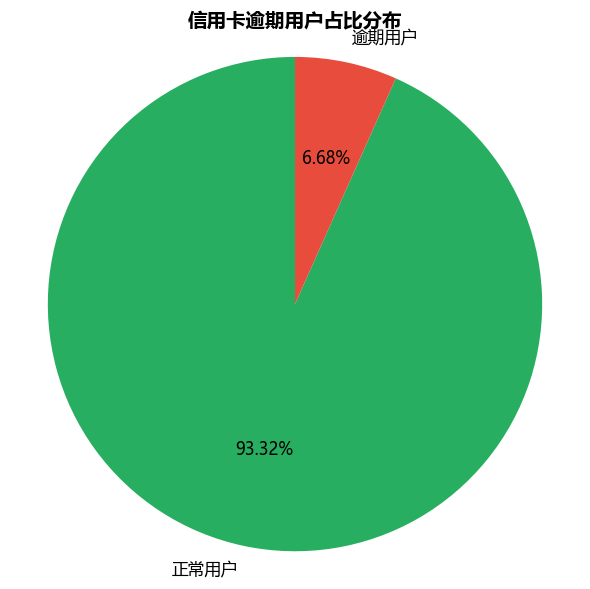

In [23]:
# ===================== 模块6：标签分布可视化 =====================
# 1. 柱状图
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x=target_col, data=df, hue=target_col,
    palette=["#27ae60", "#e74c3c"], legend=False
)
plt.title("信用卡逾期用户与正常用户数量分布", fontsize=14, fontweight="bold")
plt.xlabel("用户类型（0=正常，1=逾期）", fontsize=12)
plt.ylabel("样本数量", fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1200, f"{int(height)}", ha="center", fontsize=11)

plt.ylim(0, label_count[0] * 1.1)
plt.tight_layout()
plt.savefig("../data/output-img/标签分布数量柱状图.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. 饼图
plt.figure(figsize=(6, 6))
plt.pie(label_ratio, labels=["正常用户", "逾期用户"], autopct="%.2f%%",
        colors=["#27ae60", "#e74c3c"], startangle=90, textprops={"fontsize":12})
plt.title("信用卡逾期用户占比分布", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.savefig("../data/output-img/标签占比饼图.png", dpi=300, bbox_inches="tight")
plt.show()

## 动态总结报告(自动读取缺失 / 异常列)

In [24]:
# ===================== 模块7：【动态生成】探索报告总结（无硬编码） =====================
print("\n📋 数据集探索最终总结报告（全自动生成）：")
print(f"1. 数据集规模：共{df.shape[0]}条用户样本，{df.shape[1]-1}个输入特征+1个标签；")

# 自动总结缺失值
if not missing_result.empty:
    missing_cols = "、".join(missing_result.index.tolist())
    missing_info = "，缺失列：" + missing_cols
else:
    missing_info = "，无缺失值"
print(f"2. 缺失值：共检测到 {len(missing_result)} 列存在缺失{missing_info}；")

# 自动总结异常值
if outlier_result:
    outlier_cols = "、".join([x["特征列名"] for x in outlier_result])
    outlier_info = "，异常列：" + outlier_cols
else:
    outlier_info = "，无异常值"
print(f"3. 异常值：共检测到 {len(outlier_result)} 列存在异常{outlier_info}；")

print(f"4. 标签分布：正常用户{label_ratio[0]:.2f}%，逾期用户{label_ratio[1]:.2f}%，严重不平衡；")
print(f"5. 特征类型：全部为数值型特征，无需分类编码，可直接用于模型训练。")
print("="*70)


📋 数据集探索最终总结报告（全自动生成）：
1. 数据集规模：共150000条用户样本，10个输入特征+1个标签；
2. 缺失值：共检测到 2 列存在缺失，缺失列：MonthlyIncome、NumberOfDependents；
3. 异常值：共检测到 10 列存在异常，异常列：RevolvingUtilizationOfUnsecuredLines、age、NumberOfTime30-59DaysPastDueNotWorse、DebtRatio、MonthlyIncome、NumberOfOpenCreditLinesAndLoans、NumberOfTimes90DaysLate、NumberRealEstateLoansOrLines、NumberOfTime60-89DaysPastDueNotWorse、NumberOfDependents；
4. 标签分布：正常用户93.32%，逾期用户6.68%，严重不平衡；
5. 特征类型：全部为数值型特征，无需分类编码，可直接用于模型训练。
